In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ============================================================
# Load data
# ============================================================
meta = pd.read_csv('/scratch/leuven/387/vsc38795/postcard_color_project/20230301-Postcards-csv.csv')
labels = pd.read_csv('/scratch/leuven/387/vsc38795/postcard_color_project/output/postcard_fine_labels.csv')

meta = meta.rename(columns={
    'Colour 340$o_standardized':        'colour_orig',
    'Date 264$c_estimateDecade':        'decade',
    'Uniform title 130$a_placeNameCurrent': 'city',
    'Publisher 264$b_clean':            'publisher',
    'Resolver URL 856$u':               'resolver_url'
})
meta['IE_id'] = meta['resolver_url'].str.extract(r'/(IE\d+)/')
labels['IE_id'] = labels['image_path'].str.extract(r'/(IE\d+)/')

df = labels.merge(meta[['IE_id','decade','city','publisher','colour_orig']], 
                  on='IE_id', how='left')

print(f"Merged: {len(df)} rows")
print(df['fine_label'].value_counts())

Merged: 35930 rows
fine_label
bw                   23174
sepia                 9289
color_photo           1713
color_handcolored     1545
monotone_blue          156
monotone_green          33
monotone_red            14
monotone_purple          6
Name: count, dtype: int64


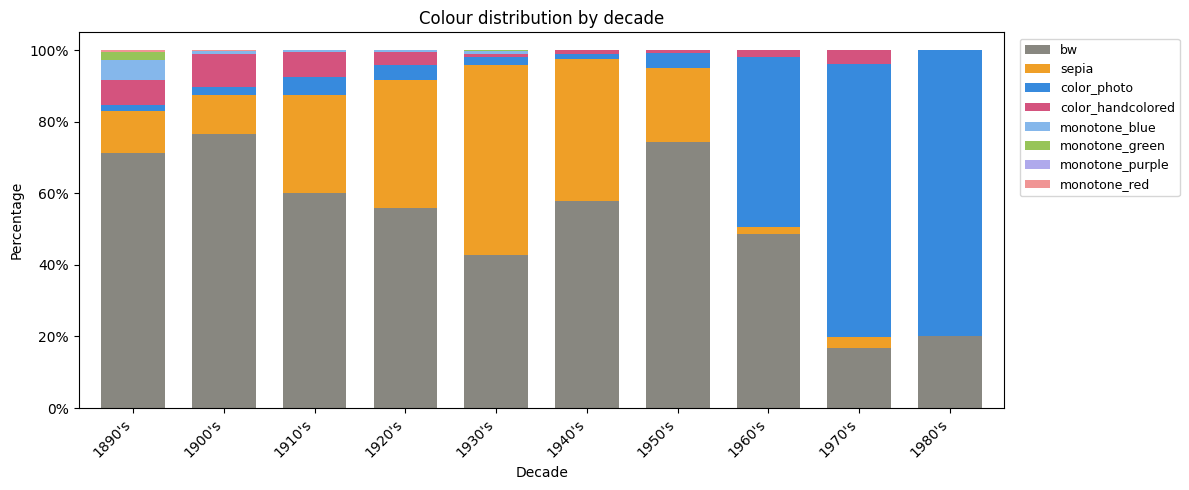

In [11]:
# ============================================================
# 1. Colour distribution by decade
# ============================================================
decade_order = ['1880\'s','1890\'s','1900\'s','1910\'s','1920\'s',
                '1930\'s','1940\'s','1950\'s','1960\'s','1970\'s','1980\'s']

decade_df = df[df['decade'].notna()].copy()
decade_counts = decade_df.groupby(['decade','fine_label']).size().unstack(fill_value=0)
decade_pct = decade_counts.div(decade_counts.sum(axis=1), axis=0) * 100

# Keep only decades with enough data
decade_pct = decade_pct.loc[decade_pct.index.isin(decade_order)]
decade_pct = decade_pct.reindex([d for d in decade_order if d in decade_pct.index])

color_map = {
   'bw':                '#888780',
    'sepia':             '#EF9F27',
    'color_photo':       '#378ADD',
    'color_handcolored': '#D4537E',
    'monotone_blue':     '#85B7EB',
    'monotone_green':    '#97C459',
    'monotone_purple':   '#AFA9EC',
    'monotone_red':      '#F09595',
}

cols = [c for c in color_map if c in decade_pct.columns]
fig, ax = plt.subplots(figsize=(12, 5))
decade_pct[cols].plot(kind='bar', stacked=True, ax=ax,
                      color=[color_map[c] for c in cols], width=0.7)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Decade')
ax.set_ylabel('Percentage')
ax.set_title('Colour distribution by decade')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

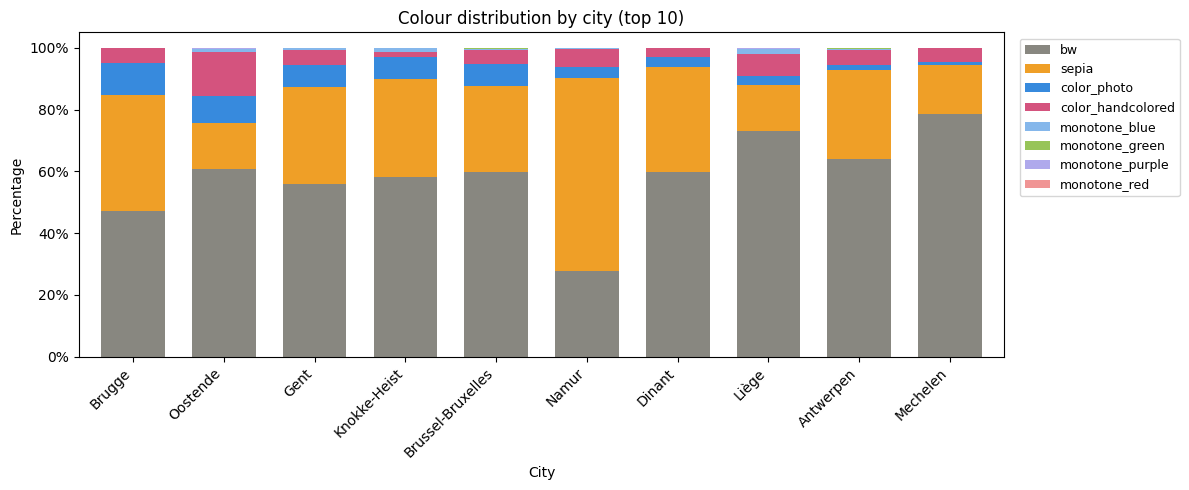

In [12]:
# ============================================================
# 2. Colour distribution by city (top 10)
# ============================================================
top_cities = df['city'].value_counts().head(10).index
city_df = df[df['city'].isin(top_cities)].copy()
city_counts = city_df.groupby(['city','fine_label']).size().unstack(fill_value=0)
city_pct = city_counts.div(city_counts.sum(axis=1), axis=0) * 100
city_pct = city_pct.sort_values('color_photo' if 'color_photo' in city_pct.columns else city_pct.columns[0], 
                                 ascending=False)

cols = [c for c in color_map if c in city_pct.columns]
fig, ax = plt.subplots(figsize=(12, 5))
city_pct[cols].plot(kind='bar', stacked=True, ax=ax,
                    color=[color_map[c] for c in cols], width=0.7)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('City')
ax.set_ylabel('Percentage')
ax.set_title('Colour distribution by city (top 10)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

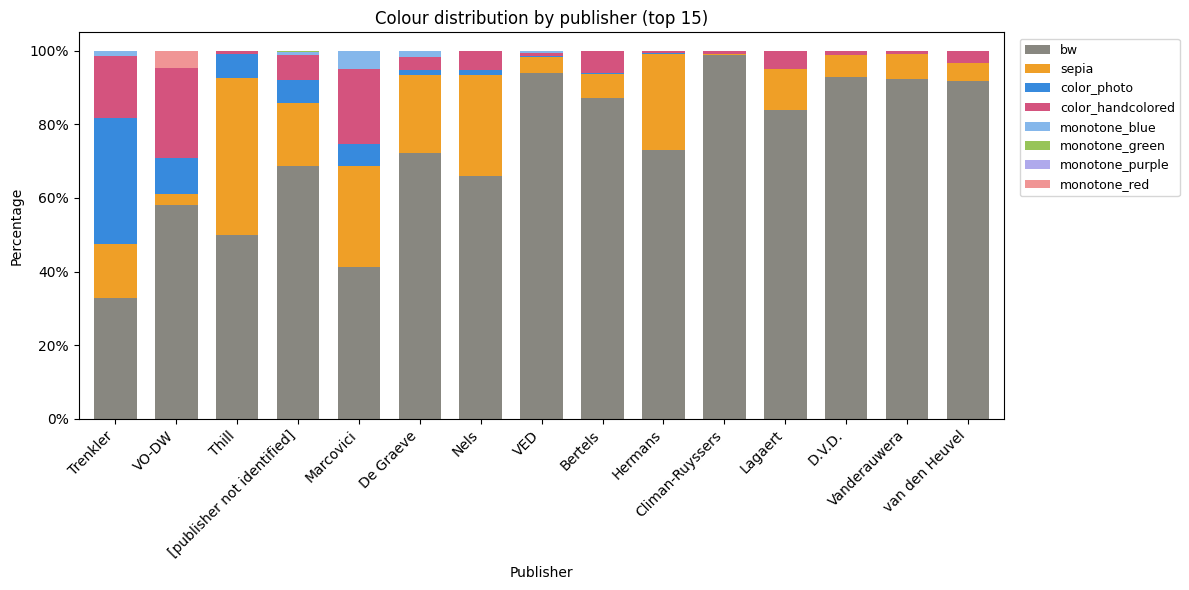

In [5]:
# ============================================================
# 3. Colour distribution by publisher (top 15)
# ============================================================
top_publishers = df['publisher'].value_counts().head(15).index
pub_df = df[df['publisher'].isin(top_publishers)].copy()
pub_counts = pub_df.groupby(['publisher','fine_label']).size().unstack(fill_value=0)
pub_pct = pub_counts.div(pub_counts.sum(axis=1), axis=0) * 100
pub_pct = pub_pct.sort_values('color_photo' if 'color_photo' in pub_pct.columns else pub_pct.columns[0],
                               ascending=False)

cols = [c for c in color_map if c in pub_pct.columns]
fig, ax = plt.subplots(figsize=(12, 6))
pub_pct[cols].plot(kind='bar', stacked=True, ax=ax,
                   color=[color_map[c] for c in cols], width=0.7)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Publisher')
ax.set_ylabel('Percentage')
ax.set_title('Colour distribution by publisher (top 15)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# 4. Key findings summary
# ============================================================
print("=== Key findings ===\n")

print("Colour by decade (% color_photo):")
if 'color_photo' in decade_pct.columns:
    print(decade_pct['color_photo'].round(1).to_string())

print("\nMost colour-rich cities:")
if 'color_photo' in city_pct.columns:
    print(city_pct['color_photo'].sort_values(ascending=False).head(5).round(1).to_string())

print("\nPublishers with most colour photos:")
if 'color_photo' in pub_pct.columns:
    print(pub_pct['color_photo'].sort_values(ascending=False).head(5).round(1).to_string())

=== Key findings ===

Colour by decade (% color_photo):
decade
1890's     1.5
1900's     2.0
1910's     5.0
1920's     4.0
1930's     2.3
1940's     1.5
1950's     4.2
1960's    47.5
1970's    76.2
1980's    80.0

Most colour-rich cities:
city
Brugge               10.3
Oostende              8.5
Gent                  7.2
Knokke-Heist          7.0
Brussel-Bruxelles     7.0

Publishers with most colour photos:
publisher
Trenkler                      34.3
VO-DW                          9.7
Thill                          6.5
[publisher not identified]     6.2
Marcovici                      6.0
